In [1]:
import os
import glob
import warnings

import pandas as pd
import numpy as np

features = pd.read_csv("hotels-europe_features.csv")
price = pd.read_csv("hotels-europe_price.csv")

df_full = pd.merge(features, price, on="hotel_id")
df_full = df_full.sort_values(["hotel_id", "year", "month"]).copy()

sequence_length = 5
prediction_horizon = 1

print(f"Prediction setting: use past {sequence_length} month(s) to predict {prediction_horizon} month(s) ahead.")
print("Raw merged data shape:", df_full.shape)


Prediction setting: use past 5 month(s) to predict 1 month(s) ahead.
Raw merged data shape: (148021, 24)


In [2]:
from pathlib import Path
import warnings

FRED_LOCAL_DIR = Path(".")  # same folder as the notebook
MIN_RECOMMENDED_FRED_INDEX_COUNT = 20

SAVE_OUTPUT_CSV_FILES = False

print("Current working directory:", Path.cwd())
print("FRED local directory:", FRED_LOCAL_DIR.resolve())

fred_config = {
     # Price level / inflation
    "inflation_cpi": {
        "category": "price_level_inflation",
        "series_ids": ["CPIAUCSL"],
        "file_patterns": ["CPIAUCSL.csv", "CPIAUCSL*.csv"],
        "raw_col": "inflation_raw",
        "index_col": "inflation_index",
        "description": "Consumer Price Index for All Urban Consumers",
        "required": True
    },
    "core_cpi": {
        "category": "price_level_inflation",
        "series_ids": ["CPILFESL"],
        "file_patterns": ["CPILFESL.csv", "CPILFESL*.csv"],
        "raw_col": "core_cpi_raw",
        "index_col": "core_cpi_index",
        "description": "Core CPI excluding food and energy",
        "required": False
    },
    "pce_price_index": {
        "category": "price_level_inflation",
        "series_ids": ["PCEPI"],
        "file_patterns": ["PCEPI.csv", "PCEPI*.csv"],
        "raw_col": "pce_price_index_raw",
        "index_col": "pce_price_index_index",
        "description": "Personal Consumption Expenditures Price Index",
        "required": False
    },
    "core_pce_price_index": {
        "category": "price_level_inflation",
        "series_ids": ["PCEPILFE"],
        "file_patterns": ["PCEPILFE.csv", "PCEPILFE*.csv"],
        "raw_col": "core_pce_price_index_raw",
        "index_col": "core_pce_price_index_index",
        "description": "Core PCE Price Index",
        "required": False
    },
    "producer_price_index": {
        "category": "price_level_inflation",
        "series_ids": ["PPIACO"],
        "file_patterns": ["PPIACO.csv", "PPIACO*.csv"],
        "raw_col": "producer_price_index_raw",
        "index_col": "producer_price_index_index",
        "description": "Producer Price Index: All Commodities",
        "required": False
    },

    # Energy / operating cost
    "energy_cpi": {
        "category": "energy_operating_cost",
        "series_ids": ["CPIENGSL"],
        "file_patterns": ["CPIENGSL.csv", "CPIENGSL*.csv"],
        "raw_col": "energy_cpi_raw",
        "index_col": "energy_cpi_index",
        "description": "CPI Energy",
        "required": False
    },
    "fuel_price": {
        "category": "energy_operating_cost",
        "series_ids": ["MCOILWTICO", "DCOILWTICO"],
        "file_patterns": ["MCOILWTICO.csv", "MCOILWTICO*.csv", "DCOILWTICO.csv", "DCOILWTICO*.csv"],
        "raw_col": "fuel_price_raw",
        "index_col": "fuel_price_index",
        "description": "WTI crude oil price, fuel-price proxy",
        "required": True
    },
    "gasoline_price": {
        "category": "energy_operating_cost",
        "series_ids": ["GASREGW"],
        "file_patterns": ["GASREGW.csv", "GASREGW*.csv"],
        "raw_col": "gasoline_price_raw",
        "index_col": "gasoline_price_index",
        "description": "US regular gasoline price",
        "required": False
    },
    "natural_gas_price": {
        "category": "energy_operating_cost",
        "series_ids": ["DHHNGSP"],
        "file_patterns": ["DHHNGSP.csv", "DHHNGSP*.csv"],
        "raw_col": "natural_gas_price_raw",
        "index_col": "natural_gas_price_index",
        "description": "Henry Hub natural gas spot price",
        "required": False
    },
    "electricity": {
        "category": "energy_operating_cost",
        "series_ids": ["CUSR0000SEHF01"],
        "file_patterns": ["CUSR0000SEHF01.csv", "CUSR0000SEHF01*.csv"],
        "raw_col": "electricity_raw",
        "index_col": "electricity_index",
        "description": "CPI for electricity",
        "required": True
    },

    # Consumer demand / spending
    "personal_consumption": {
        "category": "consumer_demand",
        "series_ids": ["PCE"],
        "file_patterns": ["PCE.csv", "PCE*.csv"],
        "raw_col": "personal_consumption_raw",
        "index_col": "personal_consumption_index",
        "description": "Personal Consumption Expenditures",
        "required": False
    },
    "services_consumption": {
        "category": "consumer_demand",
        "series_ids": ["PCES"],
        "file_patterns": ["PCES.csv", "PCES*.csv"],
        "raw_col": "services_consumption_raw",
        "index_col": "services_consumption_index",
        "description": "Personal Consumption Expenditures: Services",
        "required": False
    },
    "real_disposable_income": {
        "category": "consumer_demand",
        "series_ids": ["DSPIC96"],
        "file_patterns": ["DSPIC96.csv", "DSPIC96*.csv"],
        "raw_col": "real_disposable_income_raw",
        "index_col": "real_disposable_income_index",
        "description": "Real Disposable Personal Income",
        "required": False
    },
    "personal_saving_rate": {
        "category": "consumer_demand",
        "series_ids": ["PSAVERT"],
        "file_patterns": ["PSAVERT.csv", "PSAVERT*.csv"],
        "raw_col": "personal_saving_rate_raw",
        "index_col": "personal_saving_rate_index",
        "description": "Personal Saving Rate",
        "required": False
    },
    "retail_sales": {
        "category": "consumer_demand",
        "series_ids": ["RSAFS"],
        "file_patterns": ["RSAFS.csv", "RSAFS*.csv"],
        "raw_col": "retail_sales_raw",
        "index_col": "retail_sales_index",
        "description": "Advance Retail Sales: Retail and Food Services",
        "required": False
    },
    "retail_sales_ex_food": {
        "category": "consumer_demand",
        "series_ids": ["RSXFS"],
        "file_patterns": ["RSXFS.csv", "RSXFS*.csv"],
        "raw_col": "retail_sales_ex_food_raw",
        "index_col": "retail_sales_ex_food_index",
        "description": "Retail Sales excluding Food Services",
        "required": False
    },
    "consumer_sentiment": {
        "category": "consumer_demand",
        "series_ids": ["UMCSENT"],
        "file_patterns": ["UMCSENT.csv", "UMCSENT*.csv"],
        "raw_col": "consumer_sentiment_raw",
        "index_col": "consumer_sentiment_index",
        "description": "University of Michigan Consumer Sentiment",
        "required": False
    },

    # Labour market / wage pressure
    "unemployment_rate": {
        "category": "labour_market",
        "series_ids": ["UNRATE"],
        "file_patterns": ["UNRATE.csv", "UNRATE*.csv"],
        "raw_col": "unemployment_rate_raw",
        "index_col": "unemployment_rate_index",
        "description": "Unemployment Rate",
        "required": False
    },
    "nonfarm_payrolls": {
        "category": "labour_market",
        "series_ids": ["PAYEMS"],
        "file_patterns": ["PAYEMS.csv", "PAYEMS*.csv"],
        "raw_col": "nonfarm_payrolls_raw",
        "index_col": "nonfarm_payrolls_index",
        "description": "Total Nonfarm Payrolls",
        "required": False
    },
    "avg_hourly_earnings": {
        "category": "labour_market",
        "series_ids": ["CES0500000003"],
        "file_patterns": ["CES0500000003.csv", "CES0500000003*.csv"],
        "raw_col": "avg_hourly_earnings_raw",
        "index_col": "avg_hourly_earnings_index",
        "description": "Average Hourly Earnings, Total Private",
        "required": False
    },
    "initial_claims": {
        "category": "labour_market",
        "series_ids": ["ICSA"],
        "file_patterns": ["ICSA.csv", "ICSA*.csv"],
        "raw_col": "initial_claims_raw",
        "index_col": "initial_claims_index",
        "description": "Initial Unemployment Claims",
        "required": False
    },
    "job_openings": {
        "category": "labour_market",
        "series_ids": ["JTSJOL"],
        "file_patterns": ["JTSJOL.csv", "JTSJOL*.csv"],
        "raw_col": "job_openings_raw",
        "index_col": "job_openings_index",
        "description": "Job Openings: Total Nonfarm",
        "required": False
    },

    # Financial conditions
    "fed_funds_rate": {
        "category": "financial_conditions",
        "series_ids": ["FEDFUNDS"],
        "file_patterns": ["FEDFUNDS.csv", "FEDFUNDS*.csv"],
        "raw_col": "fed_funds_rate_raw",
        "index_col": "fed_funds_rate_index",
        "description": "Effective Federal Funds Rate",
        "required": False
    },
    "ten_year_treasury": {
        "category": "financial_conditions",
        "series_ids": ["DGS10"],
        "file_patterns": ["DGS10.csv", "DGS10*.csv"],
        "raw_col": "ten_year_treasury_raw",
        "index_col": "ten_year_treasury_index",
        "description": "10-Year Treasury Constant Maturity Rate",
        "required": False
    },
    "two_year_treasury": {
        "category": "financial_conditions",
        "series_ids": ["DGS2"],
        "file_patterns": ["DGS2.csv", "DGS2*.csv"],
        "raw_col": "two_year_treasury_raw",
        "index_col": "two_year_treasury_index",
        "description": "2-Year Treasury Constant Maturity Rate",
        "required": False
    },
    "mortgage_rate": {
        "category": "financial_conditions",
        "series_ids": ["MORTGAGE30US"],
        "file_patterns": ["MORTGAGE30US.csv", "MORTGAGE30US*.csv"],
        "raw_col": "mortgage_rate_raw",
        "index_col": "mortgage_rate_index",
        "description": "30-Year Fixed Rate Mortgage Average",
        "required": False
    },
    "financial_volatility": {
        "category": "financial_conditions",
        "series_ids": ["VIXCLS"],
        "file_patterns": ["VIXCLS.csv", "VIXCLS*.csv"],
        "raw_col": "financial_volatility_raw",
        "index_col": "financial_volatility_index",
        "description": "CBOE Volatility Index",
        "required": False
    },
    "trade_weighted_dollar": {
        "category": "financial_conditions",
        "series_ids": ["DTWEXBGS"],
        "file_patterns": ["DTWEXBGS.csv", "DTWEXBGS*.csv"],
        "raw_col": "trade_weighted_dollar_raw",
        "index_col": "trade_weighted_dollar_index",
        "description": "Trade Weighted U.S. Dollar Index",
        "required": False
    },

    # Real activity
    "industrial_production": {
        "category": "real_activity",
        "series_ids": ["INDPRO"],
        "file_patterns": ["INDPRO.csv", "INDPRO*.csv"],
        "raw_col": "industrial_production_raw",
        "index_col": "industrial_production_index",
        "description": "Industrial Production Index",
        "required": False
    },
    "housing_starts": {
        "category": "real_activity",
        "series_ids": ["HOUST"],
        "file_patterns": ["HOUST.csv", "HOUST*.csv"],
        "raw_col": "housing_starts_raw",
        "index_col": "housing_starts_index",
        "description": "Housing Starts",
        "required": False
    },
}

fred_download_checklist = pd.DataFrame([
    {
        "indicator_key": key,
        "category": cfg["category"],
        "series_ids": " or ".join(cfg["series_ids"]),
        "required": cfg["required"],
        "description": cfg["description"],
        "recommended_filename": cfg["file_patterns"][0],
        "download_url": f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={cfg['series_ids'][0]}"
    }
    for key, cfg in fred_config.items()
])
if SAVE_OUTPUT_CSV_FILES:
    fred_download_checklist.to_csv("fred_20_30_index_download_checklist.csv", index=False)
    print("FRED download checklist saved to fred_20_30_index_download_checklist.csv")
else:
    print("FRED download checklist is displayed below; no CSV file is saved.")
display(fred_download_checklist.head(10))


def find_local_fred_file(cfg, local_dir=FRED_LOCAL_DIR):
    """
    Find the first local CSV file matching the expected FRED file pattern.
    If filenames were not renamed, it also scans CSV headers for the FRED series ID.
    """
    local_dir = Path(local_dir)
    matches = []

    for pattern in cfg["file_patterns"]:
        matches.extend(sorted(local_dir.glob(pattern)))

    # Remove duplicates while preserving order.
    unique_matches = []
    seen = set()
    for path in matches:
        if path not in seen:
            unique_matches.append(path)
            seen.add(path)

    if unique_matches:
        return unique_matches[0]

    for csv_path in sorted(local_dir.glob("*.csv")):
        try:
            header = pd.read_csv(csv_path, nrows=0).columns.astype(str).tolist()
        except Exception:
            continue
        if any(series_id in header for series_id in cfg["series_ids"]):
            return csv_path

    return None


def standardize_local_fred_dataframe(temp, series_ids, raw_col, source_path):
    """
    Standardize a FRED CSV into two columns:
        date, raw_col

    Works for common FRED formats:
        DATE, CPIAUCSL
        observation_date, CPIAUCSL
        date, value
    """
    temp = temp.copy()
    temp.columns = [str(c).strip() for c in temp.columns]

    date_candidates = [c for c in temp.columns if c.lower() in ["date", "observation_date"]]
    if date_candidates:
        date_col = date_candidates[0]
    else:
        date_col = temp.columns[0]

    value_col = None
    for sid in series_ids:
        if sid in temp.columns:
            value_col = sid
            break

    if value_col is None:
        non_date_cols = [c for c in temp.columns if c != date_col]
        if not non_date_cols:
            raise ValueError(f"No value column found in {source_path}")
        value_col = non_date_cols[0]

    temp = temp[[date_col, value_col]].rename(columns={date_col: "date", value_col: raw_col})
    temp["date"] = pd.to_datetime(temp["date"], errors="coerce")
    temp[raw_col] = pd.to_numeric(temp[raw_col], errors="coerce")
    temp = temp.dropna(subset=["date"])
    temp = temp.sort_values("date").drop_duplicates(subset=["date"], keep="last")
    return temp


def load_fred_series_from_local_csv(cfg, start_date, end_date):
    """Load one FRED series from local CSV. Returns None when an optional file is missing."""
    source_path = find_local_fred_file(cfg)

    if source_path is None:
        return None, None

    print(f"Loading local FRED file for {cfg['description']}: {source_path}")
    temp = pd.read_csv(source_path)
    temp = standardize_local_fred_dataframe(
        temp=temp,
        series_ids=cfg["series_ids"],
        raw_col=cfg["raw_col"],
        source_path=source_path
    )

    # Restrict to study period, with buffer for YoY calculation.
    temp = temp[
        (temp["date"] >= pd.Timestamp(start_date)) &
        (temp["date"] <= pd.Timestamp(end_date))
    ]

    if temp.empty:
        warnings.warn(
            f"{source_path} has no observations between "
            f"{pd.Timestamp(start_date).date()} and {pd.Timestamp(end_date).date()}. "
            "This optional FRED series will be skipped."
        )
        return None, source_path.name

    # Convert daily, weekly, monthly, or quarterly data to one monthly value.
    # Daily/weekly series become monthly averages. Quarterly series are forward-filled after resampling.
    monthly = temp.set_index("date")[[cfg["raw_col"]]].resample("MS").mean()
    monthly[cfg["raw_col"]] = monthly[cfg["raw_col"]].ffill().bfill()
    monthly = monthly.reset_index()

    if monthly[cfg["raw_col"]].dropna().empty:
        warnings.warn(f"{source_path} has no valid numeric values after cleaning. It will be skipped.")
        return None, source_path.name

    print(f"Loaded {source_path.name}. Monthly rows: {len(monthly)}")
    return monthly, source_path.name


def build_fred_monthly_features(start_date, end_date):
    """
    Build monthly FRED index features and percentage-change features from local CSV files.

    For each loaded FRED series:
        raw value      -> used only to construct index
        index value    -> base 100 at first valid observation in the study window
        MoM change     -> pct_change(1)
        YoY change     -> pct_change(12)
    """
    frames = []
    load_status = []
    missing_required = []

    for name, cfg in fred_config.items():
        raw_col = cfg["raw_col"]
        index_col = cfg["index_col"]

        temp, used_file = load_fred_series_from_local_csv(
            cfg=cfg,
            start_date=start_date,
            end_date=end_date
        )

        if temp is None:
            load_status.append({
                "indicator_key": name,
                "category": cfg["category"],
                "loaded": False,
                "used_file": used_file,
                "required": cfg["required"],
                "series_ids": " or ".join(cfg["series_ids"]),
                "description": cfg["description"],
                "download_url": f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={cfg['series_ids'][0]}"
            })
            if cfg["required"]:
                missing_required.append(name)
            continue

        first_valid_series = temp[raw_col].dropna()
        first_valid = first_valid_series.iloc[0]

        # Convert raw series to an index, base = first available value in the study window.
        temp[index_col] = temp[raw_col] / first_valid * 100

        # Create month-on-month and year-on-year percentage changes.
        temp[f"{index_col}_mom"] = temp[index_col].pct_change()
        temp[f"{index_col}_yoy"] = temp[index_col].pct_change(12)

        frames.append(temp[["date", index_col, f"{index_col}_mom", f"{index_col}_yoy"]])

        load_status.append({
            "indicator_key": name,
            "category": cfg["category"],
            "loaded": True,
            "used_file": used_file,
            "required": cfg["required"],
            "series_ids": " or ".join(cfg["series_ids"]),
            "description": cfg["description"],
            "index_col": index_col,
            "mom_col": f"{index_col}_mom",
            "yoy_col": f"{index_col}_yoy",
            "download_url": f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={cfg['series_ids'][0]}"
        })

    fred_load_status_df = pd.DataFrame(load_status)
    if SAVE_OUTPUT_CSV_FILES:
        fred_load_status_df.to_csv("fred_load_status.csv", index=False)

    missing_optional_df = fred_load_status_df[fred_load_status_df["loaded"] == False].copy()
    if SAVE_OUTPUT_CSV_FILES:
        missing_optional_df.to_csv("fred_missing_optional_download_list.csv", index=False)

    if missing_required:
        required_message = fred_load_status_df[
            (fred_load_status_df["indicator_key"].isin(missing_required))
        ][["indicator_key", "series_ids", "download_url"]]
        raise FileNotFoundError(
            "Required FRED CSV files are missing. Please download these files into the notebook folder:\n"
            + required_message.to_string(index=False)
        )

    if not frames:
        raise FileNotFoundError(
            "No FRED CSV files were found. Please place the FRED CSV files in the same folder as this notebook."
        )

    fred_df = frames[0]
    for frame in frames[1:]:
        fred_df = fred_df.merge(frame, on="date", how="outer")

    fred_df = fred_df.sort_values("date").copy()
    fred_df["year"] = fred_df["date"].dt.year
    fred_df["month"] = fred_df["date"].dt.month

    return fred_df.drop(columns=["date"]), fred_load_status_df


# The buffer supports YoY calculations before the first hotel observation month.
start_date = pd.Timestamp(int(df_full["year"].min()), int(df_full["month"].min()), 1) - pd.DateOffset(months=18)
end_date = pd.Timestamp(int(df_full["year"].max()), int(df_full["month"].max()), 1) + pd.DateOffset(months=1)

print("Study FRED date range:", start_date.date(), "to", end_date.date())

fred_monthly, fred_load_status_df = build_fred_monthly_features(start_date, end_date)

loaded_fred_status = fred_load_status_df[fred_load_status_df["loaded"] == True].copy()
loaded_indicator_keys = loaded_fred_status["indicator_key"].tolist()

print(f"Loaded FRED indicators: {len(loaded_indicator_keys)}")
print("Loaded indicator keys:", loaded_indicator_keys)

if len(loaded_indicator_keys) < MIN_RECOMMENDED_FRED_INDEX_COUNT:
    warnings.warn(
        f"Only {len(loaded_indicator_keys)} FRED indicator(s) were loaded. "
        f"The supervisor's '20-30 index' note is better addressed by downloading at least "
        f"{MIN_RECOMMENDED_FRED_INDEX_COUNT} CSV files from fred_20_30_index_download_checklist.csv. "
        "The notebook will still run with the available indicators."
    )

# Merge FRED monthly features by year and month.
df_full = df_full.merge(fred_monthly, on=["year", "month"], how="left")

# Build feature groups dynamically based on the FRED files actually found.
fred_index_cols = []
fred_change_cols = []
fred_indicator_feature_groups = {}
fred_category_index_groups = {}
fred_category_all_feature_groups = {}

for _, row in loaded_fred_status.iterrows():
    key = row["indicator_key"]
    cfg = fred_config[key]
    index_col = cfg["index_col"]
    mom_col = f"{index_col}_mom"
    yoy_col = f"{index_col}_yoy"

    candidate_cols = [index_col, mom_col, yoy_col]
    existing_cols = [c for c in candidate_cols if c in df_full.columns]

    if index_col in df_full.columns:
        fred_index_cols.append(index_col)
    fred_change_cols.extend([c for c in [mom_col, yoy_col] if c in df_full.columns])
    fred_indicator_feature_groups[key] = existing_cols

    category = cfg["category"]
    fred_category_index_groups.setdefault(category, [])
    fred_category_all_feature_groups.setdefault(category, [])

    if index_col in df_full.columns:
        fred_category_index_groups[category].append(index_col)
    fred_category_all_feature_groups[category].extend(existing_cols)


core_indicator_keys = ["inflation_cpi", "fuel_price", "electricity"]
core_fred_change_cols = []
for key in core_indicator_keys:
    for c in fred_indicator_feature_groups.get(key, [])[1:]:
        if c in df_full.columns:
            core_fred_change_cols.append(c)

# This is the feature set used by the main model.
exogenous_cols = fred_index_cols + core_fred_change_cols
exogenous_cols = [c for c in exogenous_cols if c in df_full.columns]

# This is the larger feature pool used for expanded ablation experiments.
fred_all_feature_cols = fred_index_cols + fred_change_cols
fred_all_feature_cols = [c for c in fred_all_feature_cols if c in df_full.columns]

# Compatibility aliases for the original 3 variables.
# If the original column names are expected elsewhere, these names remain available:
#   inflation_index, fuel_price_index, and electricity_index keep the original core names.

# Clean possible missing values in FRED features created at the beginning of the period.
df_full[fred_all_feature_cols] = df_full[fred_all_feature_cols].replace([np.inf, -np.inf], np.nan)
df_full[fred_all_feature_cols] = df_full[fred_all_feature_cols].ffill().bfill()

print("FRED monthly features shape:", fred_monthly.shape)
print("Main exogenous columns used by model:", exogenous_cols)
print("Full FRED feature pool for ablation:", len(fred_all_feature_cols), "columns")
print("FRED category groups:")
for category, cols in fred_category_index_groups.items():
    print(f"  {category}: {len(cols)} index column(s)")

display(loaded_fred_status[["indicator_key", "category", "series_ids", "used_file", "description"]])
print(df_full[["year", "month"] + exogenous_cols].drop_duplicates().head(15))

Current working directory: C:\Users\47193\Hotel price prediction
FRED local directory: C:\Users\47193\Hotel price prediction
FRED download checklist is displayed below; no CSV file is saved.


,indicator_key,category,series_ids,required,description,recommended_filename,download_url
0,inflation_cpi,price_level_inflation,CPIAUCSL,True,Consumer Price Index for All Urban Consumers,CPIAUCSL.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
1,core_cpi,price_level_inflation,CPILFESL,False,Core CPI excluding food and energy,CPILFESL.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
2,pce_price_index,price_level_inflation,PCEPI,False,Personal Consumption Expenditures Price Index,PCEPI.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
3,core_pce_price_index,price_level_inflation,PCEPILFE,False,Core PCE Price Index,PCEPILFE.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
4,producer_price_index,price_level_inflation,PPIACO,False,Producer Price Index: All Commodities,PPIACO.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
5,energy_cpi,energy_operating_cost,CPIENGSL,False,CPI Energy,CPIENGSL.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
6,fuel_price,energy_operating_cost,MCOILWTICO or DCOILWTICO,True,"WTI crude oil price, fuel-price proxy",MCOILWTICO.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
7,gasoline_price,energy_operating_cost,GASREGW,False,US regular gasoline price,GASREGW.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
8,natural_gas_price,energy_operating_cost,DHHNGSP,False,Henry Hub natural gas spot price,DHHNGSP.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...
9,electricity,energy_operating_cost,CUSR0000SEHF01,True,CPI for electricity,CUSR0000SEHF01.csv,https://fred.stlouisfed.org/graph/fredgraph.cs...


Study FRED date range: 2015-07-01 to 2019-01-01
Loading local FRED file for Consumer Price Index for All Urban Consumers: CPIAUCSL.csv
Loaded CPIAUCSL.csv. Monthly rows: 43
Loading local FRED file for Core CPI excluding food and energy: CPILFESL.csv
Loaded CPILFESL.csv. Monthly rows: 43
Loading local FRED file for Personal Consumption Expenditures Price Index: PCEPI.csv
Loaded PCEPI.csv. Monthly rows: 43
Loading local FRED file for Core PCE Price Index: PCEPILFE.csv
Loaded PCEPILFE.csv. Monthly rows: 43
Loading local FRED file for Producer Price Index: All Commodities: PPIACO.csv
Loaded PPIACO.csv. Monthly rows: 43
Loading local FRED file for CPI Energy: CPIENGSL.csv
Loaded CPIENGSL.csv. Monthly rows: 43
Loading local FRED file for WTI crude oil price, fuel-price proxy: MCOILWTICO.csv
Loaded MCOILWTICO.csv. Monthly rows: 43
Loading local FRED file for US regular gasoline price: GASREGW.csv
Loaded GASREGW.csv. Monthly rows: 42
Loading local FRED file for CPI for electricity: CUSR0000SEH

,indicator_key,category,series_ids,used_file,description
0,inflation_cpi,price_level_inflation,CPIAUCSL,CPIAUCSL.csv,Consumer Price Index for All Urban Consumers
1,core_cpi,price_level_inflation,CPILFESL,CPILFESL.csv,Core CPI excluding food and energy
2,pce_price_index,price_level_inflation,PCEPI,PCEPI.csv,Personal Consumption Expenditures Price Index
3,core_pce_price_index,price_level_inflation,PCEPILFE,PCEPILFE.csv,Core PCE Price Index
4,producer_price_index,price_level_inflation,PPIACO,PPIACO.csv,Producer Price Index: All Commodities
5,energy_cpi,energy_operating_cost,CPIENGSL,CPIENGSL.csv,CPI Energy
6,fuel_price,energy_operating_cost,MCOILWTICO or DCOILWTICO,MCOILWTICO.csv,"WTI crude oil price, fuel-price proxy"
7,gasoline_price,energy_operating_cost,GASREGW,GASREGW.csv,US regular gasoline price
9,electricity,energy_operating_cost,CUSR0000SEHF01,CUSR0000SEHF01.csv,CPI for electricity
10,personal_consumption,consumer_demand,PCE,PCE.csv,Personal Consumption Expenditures


    year  month  inflation_index  core_cpi_index  pce_price_index_index  \
0   2017     11       103.885999      104.638344             103.145331   
2   2017     12       104.104876      104.856018             103.294913   
4   2018      1       104.547670      105.210562             103.682188   
5   2018      2       104.829142      105.419578             103.904513   
22  2018      3       104.849307      105.650444             104.015163   
23  2018      4       105.122377      105.798446             104.263101   
24  2018      5       105.359739      106.010760             104.442395   
25  2018      6       105.454683      106.115474             104.532555   

    core_pce_price_index_index  producer_price_index_index  energy_cpi_index  \
0                   103.667842                  101.031460        100.672895   
2                   103.820454                  101.237751        100.921922   
4                   104.154551                  102.062919        102.472321   
5   

In [3]:
base_tabular_cols = [
    "distance", "stars", "rating", "rating_reviewcount",
    "ratingta", "ratingta_count", "distance_alter",
    "city", "accommodation_type", "offer", "offer_cat",
    "year", "month", "weekend", "holiday", "nnights", "scarce_room"
]

base_tabular_cols = [c for c in base_tabular_cols if c in df_full.columns]

# The final tabular model uses original hotel/search/date variables + expanded FRED index variables.
tabular_cols = base_tabular_cols + exogenous_cols

rows = []

for hotel_id, group in df_full.groupby("hotel_id"):
    group = group.sort_values(["year", "month"]).reset_index(drop=True)

    if len(group) <= sequence_length + prediction_horizon - 1:
        continue

    for i in range(len(group) - sequence_length - prediction_horizon + 1):
        history_window = group.loc[i:i + sequence_length - 1]
        forecast_origin_row = group.loc[i + sequence_length - 1]
        target_row = group.loc[i + sequence_length + prediction_horizon - 1]

        hist_prices = history_window["price"].values

        row = {
            "hotel_id": hotel_id,
            "target_price": target_row["price"],
            "target_year": target_row["year"],
            "target_month": target_row["month"],
            "origin_year": forecast_origin_row["year"],
            "origin_month": forecast_origin_row["month"],
            "prediction_horizon": prediction_horizon
        }

        for j in range(sequence_length):
            row[f"hist_price_{j + 1}"] = hist_prices[j]

        # Hotel/search/date variables are taken from the target row because these are the row-level
        # covariates used in the original model. Month/year are known calendar features.
        for col in base_tabular_cols:
            row[col] = target_row[col]

        # FRED index variables are taken from the forecast origin month to avoid future information leakage.
        for col in exogenous_cols:
            row[col] = forecast_origin_row[col]

        rows.append(row)

aligned_df = pd.DataFrame(rows)

print("Aligned supervised data shape:", aligned_df.shape)
print("Base tabular columns:", base_tabular_cols)
print("Expanded FRED columns used by the main model:", exogenous_cols)
print(aligned_df.head())


Aligned supervised data shape: (53700, 58)
Base tabular columns: ['distance', 'stars', 'rating', 'rating_reviewcount', 'ratingta', 'ratingta_count', 'distance_alter', 'city', 'accommodation_type', 'offer', 'offer_cat', 'year', 'month', 'weekend', 'holiday', 'nnights', 'scarce_room']
Expanded FRED columns used by the main model: ['inflation_index', 'core_cpi_index', 'pce_price_index_index', 'core_pce_price_index_index', 'producer_price_index_index', 'energy_cpi_index', 'fuel_price_index', 'gasoline_price_index', 'electricity_index', 'personal_consumption_index', 'services_consumption_index', 'real_disposable_income_index', 'personal_saving_rate_index', 'retail_sales_index', 'retail_sales_ex_food_index', 'consumer_sentiment_index', 'unemployment_rate_index', 'nonfarm_payrolls_index', 'avg_hourly_earnings_index', 'job_openings_index', 'fed_funds_rate_index', 'industrial_production_index', 'housing_starts_index', 'inflation_index_mom', 'inflation_index_yoy', 'fuel_price_index_mom', 'fuel_p

## Prepare model inputs

This section prepares two model inputs:

- Sequential input: previous monthly hotel prices for LSTM.
- Tabular input: hotel/search/date features plus FRED index features for MLP and multimodal models.


In [4]:
X_seq = aligned_df[[f"hist_price_{i + 1}" for i in range(sequence_length)]].values
y_seq = aligned_df["target_price"].values

# Reshape to (samples, time_steps, features)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

X_tab = aligned_df[tabular_cols].copy()
y_tab = aligned_df["target_price"].values

categorical_cols = [
    col for col in ["city", "accommodation_type", "offer", "offer_cat"]
    if col in X_tab.columns and (X_tab[col].dtype == "object" or str(X_tab[col].dtype) == "category")
]

X_tab = pd.get_dummies(X_tab, columns=categorical_cols, drop_first=True)

# Robust imputation for numeric, one-hot, and FRED change columns.
X_tab = X_tab.replace([np.inf, -np.inf], np.nan)
X_tab = X_tab.fillna(X_tab.mean(numeric_only=True))
X_tab = X_tab.fillna(0)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("X_tab shape:", X_tab.shape)
print("y_tab shape:", y_tab.shape)
print("Categorical columns encoded:", categorical_cols)


X_seq shape: (53700, 5, 1)
y_seq shape: (53700,)
X_tab shape: (53700, 111)
y_tab shape: (53700,)
Categorical columns encoded: ['city', 'accommodation_type', 'offer_cat']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential, Model
from keras.layers import Input, Dense, LSTM, Concatenate, Add, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    nonzero_mask = y_true != 0
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": mape,
        "R2": r2_score(y_true, y_pred)
    }


scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_seq_scaled = scaler_x.fit_transform(X_seq.reshape(-1, 1)).reshape(X_seq.shape[0], X_seq.shape[1], 1)
y_seq_scaled = scaler_y.fit_transform(y_seq.reshape(-1, 1)).flatten()

indices = np.arange(len(aligned_df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_train_tab = X_tab.iloc[train_idx]
X_test_tab = X_tab.iloc[test_idx]
y_train_tab = y_tab[train_idx]
y_test_tab = y_tab[test_idx]

X_train_seq = X_seq_scaled[train_idx]
X_test_seq = X_seq_scaled[test_idx]
y_train_seq = y_seq_scaled[train_idx]
y_test_seq = y_seq_scaled[test_idx]

y_test_real = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

print("X_train_tab:", X_train_tab.shape)
print("X_test_tab:", X_test_tab.shape)
print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)


D:\ProgramData\Anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


X_train_tab: (42960, 111)
X_test_tab: (10740, 111)
X_train_seq: (42960, 5, 1)
X_test_seq: (10740, 5, 1)


## Baseline models

The notebook keeps the original baseline structure and compares:

- Linear Regression
- MLP
- LSTM
- Multimodal MLP + LSTM + FRED index variables


In [6]:
model_lstm = Sequential([
    LSTM(64, input_shape=(sequence_length, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=10,
    batch_size=128,
    callbacks=[early_stop],
    validation_split=0.2,
    verbose=1
)

pred_lstm_scaled = model_lstm.predict(X_test_seq).flatten()
pred_lstm = scaler_y.inverse_transform(pred_lstm_scaled.reshape(-1, 1)).flatten()

lstm_metrics = regression_metrics(y_test_real, pred_lstm)
rmse_lstm = lstm_metrics["RMSE"]
mae_lstm = lstm_metrics["MAE"]

print("LSTM metrics:", lstm_metrics)


D:\ProgramData\Anaconda3\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5159 - val_loss: 0.2967
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3114 - val_loss: 0.2636
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3624 - val_loss: 0.2571
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2377 - val_loss: 0.2474
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2423 - val_loss: 0.2388
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2354 - val_loss: 0.2297
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2422 - val_loss: 0.2330
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2190 - val_loss: 0.2334
Epoch 9/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2357 - val_loss: 0.2462
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM metrics: {'RMSE': 75.5266153585709, 'MAE': 24.55292470779277, 'MAPE': 16.55847135872091, 'R2': 0.7047253279886361}


In [7]:
# Baseline 2: Linear Regression using tabular variables + FRED indexes
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_tab, y_train_tab)
pred_lr = model_lr.predict(X_test_tab)

lr_metrics = regression_metrics(y_test_tab, pred_lr)
rmse_lr = lr_metrics["RMSE"]
mae_lr = lr_metrics["MAE"]

print("Linear Regression metrics:", lr_metrics)


Linear Regression metrics: {'RMSE': 115.0185994912519, 'MAE': 53.139512256615696, 'MAPE': 44.143363243689436, 'R2': 0.3152022879235198}


In [8]:
# Baseline 3: MLP using tabular variables + FRED indexes
from sklearn.neural_network import MLPRegressor

scaler_tab = StandardScaler()
X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
X_test_tab_scaled = scaler_tab.transform(X_test_tab)

model_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42
)
model_mlp.fit(X_train_tab_scaled, y_train_tab)
pred_mlp = model_mlp.predict(X_test_tab_scaled)

mlp_metrics = regression_metrics(y_test_tab, pred_mlp)
rmse_mlp = mlp_metrics["RMSE"]
mae_mlp = mlp_metrics["MAE"]

print("MLP metrics:", mlp_metrics)


MLP metrics: {'RMSE': 92.62335477111226, 'MAE': 45.87013843506707, 'MAPE': 38.064721274039535, 'R2': 0.5559139161278033}


D:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## Multimodal model: MLP + LSTM +  FRED index variables

This model combines:
- Tabular branch: hotel/search/date/expanded FRED index features
- Time-series branch: historical prices
- Fusion branch with residual connection


In [9]:
# Multimodal model: tabular hotel/search/FRED features + historical price sequence
scaler_fusion_tab = StandardScaler()
X_train_tab_scaled_fusion = scaler_fusion_tab.fit_transform(X_train_tab)
X_test_tab_scaled_fusion = scaler_fusion_tab.transform(X_test_tab)

# Tabular branch
input_tab = Input(shape=(X_train_tab_scaled_fusion.shape[1],), name="tabular_input")
x_tab = Dense(64, activation="relu")(input_tab)
x_tab = Dense(32, activation="relu")(x_tab)

# Sequence branch
input_seq = Input(shape=(sequence_length, 1), name="price_history_input")
x_seq = LSTM(32)(input_seq)

# Fusion + residual connection
combined = Concatenate(name="feature_fusion")([x_tab, x_seq])
shortcut = Dense(32, use_bias=False, name="residual_projection")(combined)
x = Dense(32, activation="relu")(combined)
x = Add(name="residual_add")([x, shortcut])
output = Dense(1, name="price_output")(x)

model_fusion = Model(inputs=[input_tab, input_seq], outputs=output)
model_fusion.compile(optimizer="adam", loss="mse")
model_fusion.summary()

history_fusion = model_fusion.fit(
    [X_train_tab_scaled_fusion, X_train_seq],
    y_train_seq,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

pred_fusion_scaled = model_fusion.predict([X_test_tab_scaled_fusion, X_test_seq]).flatten()
pred_fusion = scaler_y.inverse_transform(pred_fusion_scaled.reshape(-1, 1)).flatten()

fusion_metrics = regression_metrics(y_test_real, pred_fusion)
rmse_mm_tab_time = fusion_metrics["RMSE"]
mae_mm_tab_time = fusion_metrics["MAE"]

print("Fusion model metrics:", fusion_metrics)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ tabular_input (InputLayer)    │ (None, 111)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 64)                │           7,168 │ tabular_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ price_history_input           │ (None, 5, 1)              │               0 │ -                          │
│ (InputLayer)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 32)                │           2,080 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 32)                │           4,352 │ price_history_input[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feature_fusion (Concatenate)  │ (None, 64)                │               0 │ dense_3[0][0],             │
│                               │                           │                 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 32)                │           2,080 │ feature_fusion[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ residual_projection (Dense)   │ (None, 32)                │           2,048 │ feature_fusion[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ residual_add (Add)            │ (None, 32)                │               0 │ dense_4[0][0],             │
│                               │                           │                 │ residual_projection[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ price_output (Dense)          │ (None, 1)                 │              33 │ residual_add[0][0]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 17,761 (69.38 KB)

 Trainable params: 17,761 (69.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4717 - val_loss: 0.2953
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2185 - val_loss: 0.2548
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2463 - val_loss: 0.2315
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2272 - val_loss: 0.2101
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2088 - val_loss: 0.2102
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1826 - val_loss: 0.2131
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1714 - val_loss: 0.1988
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1858 - val_loss: 0.2031
Epoch 9/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1937 - val_loss: 0.1931
Epoch 10/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1671 - val_loss: 0.2076
336/336 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fusion model metrics: {'RMSE': 72.13279873775929, 'MAE': 25.97076511605048, 'MAPE': 19.20375375747

In [10]:
results_df = pd.DataFrame([
    {"Model": "Linear Regression", **lr_metrics},
    {"Model": "MLP", **mlp_metrics},
    {"Model": "LSTM", **lstm_metrics},
    {"Model": "MM(MLP+LSTM+Expanded FRED Index)", **fusion_metrics},
]).sort_values("RMSE").reset_index(drop=True)

print(results_df)
if SAVE_OUTPUT_CSV_FILES:
    results_df.to_csv("main_model_comparison_results.csv", index=False)


                              Model        RMSE        MAE       MAPE  \
0  MM(MLP+LSTM+Expanded FRED Index)   72.132799  25.970765  19.203754   
1                              LSTM   75.526615  24.552925  16.558471   
2                               MLP   92.623355  45.870138  38.064721   
3                 Linear Regression  115.018599  53.139512  44.143363   

         R2  
0  0.730666  
1  0.704725  
2  0.555914  
3  0.315202  


## General ablation study

This table tests whether adding FRED index variables improves performance compared with using only historical price and hotel/search features.  

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


def prepare_tabular_matrix(selected_cols):
    selected_cols = [c for c in selected_cols if c in aligned_df.columns]
    X = aligned_df[selected_cols].copy()

    cat_cols = [c for c in X.columns if X[c].dtype == "object" or str(X[c].dtype) == "category"]
    num_cols = [c for c in X.columns if c not in cat_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols)
        ],
        remainder="drop"
    )

    return X, preprocessor


def evaluate_ablation_model(feature_set_name, selected_cols, estimator):
    X_raw, preprocessor = prepare_tabular_matrix(selected_cols)

    X_train_raw = X_raw.iloc[train_idx]
    X_test_raw = X_raw.iloc[test_idx]

    model = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

    model.fit(X_train_raw, y_train_tab)
    pred = model.predict(X_test_raw)
    metrics = regression_metrics(y_test_tab, pred)

    return {
        "Feature_Set": feature_set_name,
        "Model": estimator.__class__.__name__,
        "Num_Features_Before_Encoding": len([c for c in selected_cols if c in aligned_df.columns]),
        **metrics
    }


hist_price_cols = [f"hist_price_{i + 1}" for i in range(sequence_length)]
hotel_search_cols = base_tabular_cols
macro_index_cols = exogenous_cols

ablation_specs = [
    ("History only", hist_price_cols),
    ("Hotel/search only", hotel_search_cols),
    ("Hotel/search + FRED indexes", hotel_search_cols + macro_index_cols),
    ("History + hotel/search", hist_price_cols + hotel_search_cols),
    ("History + hotel/search + FRED indexes", hist_price_cols + hotel_search_cols + macro_index_cols),
]

ablation_rows = []
for feature_set_name, cols in ablation_specs:
    ablation_rows.append(evaluate_ablation_model(feature_set_name, cols, Ridge(alpha=1.0)))
    ablation_rows.append(evaluate_ablation_model(
        feature_set_name,
        cols,
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12)
    ))

ablation_df = pd.DataFrame(ablation_rows).sort_values(["Model", "RMSE"]).reset_index(drop=True)
print(ablation_df)
if SAVE_OUTPUT_CSV_FILES:
    ablation_df.to_csv("general_ablation_results.csv", index=False)


                             Feature_Set                  Model  \
0                 History + hotel/search  RandomForestRegressor   
1  History + hotel/search + FRED indexes  RandomForestRegressor   
2                           History only  RandomForestRegressor   
3                      Hotel/search only  RandomForestRegressor   
4            Hotel/search + FRED indexes  RandomForestRegressor   
5  History + hotel/search + FRED indexes                  Ridge   
6                 History + hotel/search                  Ridge   
7                           History only                  Ridge   
8            Hotel/search + FRED indexes                  Ridge   
9                      Hotel/search only                  Ridge   

   Num_Features_Before_Encoding        RMSE        MAE       MAPE        R2  
0                            22   68.363136  23.628159  15.743739  0.758081  
1                            51   69.448672  23.549846  15.708895  0.750337  
2                           

## Expanded index ablation study
It compares:
- no FRED indexes
- all loaded FRED index values
- all loaded FRED index values plus core MoM/YoY changes
- each macroeconomic category separately
- leave-one-category-out experiments

In [12]:
baseline_cols = hist_price_cols + hotel_search_cols

# Index-only feature pool: one normalized base-100 index for each loaded FRED series.
all_loaded_fred_index_cols = [c for c in fred_index_cols if c in aligned_df.columns]

# Full FRED feature pool: index + MoM/YoY changes.
all_loaded_fred_feature_cols = [c for c in fred_all_feature_cols if c in aligned_df.columns]

# Main-model FRED feature set: all normalized indexes plus core MoM/YoY.
main_model_fred_cols = [c for c in exogenous_cols if c in aligned_df.columns]

print("Number of loaded FRED index columns:", len(all_loaded_fred_index_cols))
print("Number of loaded FRED feature columns including MoM/YoY:", len(all_loaded_fred_feature_cols))
print("Number of main-model FRED columns:", len(main_model_fred_cols))

index_ablation_specs = []

# 1. Baseline without FRED.
index_ablation_specs.append(("Baseline: no FRED index", baseline_cols))

# 2. Supervisor-style expanded index pool.
index_ablation_specs.append(("Baseline + all loaded FRED index values", baseline_cols + all_loaded_fred_index_cols))

# 3. Main model feature version.
index_ablation_specs.append(("Baseline + main FRED features", baseline_cols + main_model_fred_cols))

# 4. Full pool including all MoM/YoY features.
index_ablation_specs.append(("Baseline + all FRED index/MoM/YoY features", baseline_cols + all_loaded_fred_feature_cols))

# 5. Add one macroeconomic category at a time.
for category, cols in fred_category_index_groups.items():
    cols = [c for c in cols if c in aligned_df.columns]
    if cols:
        index_ablation_specs.append((f"Baseline + category: {category}", baseline_cols + cols))

# 6. Leave one macroeconomic category out from the full index-value pool.
for category, cols in fred_category_index_groups.items():
    cols = [c for c in cols if c in aligned_df.columns]
    if cols:
        remaining = [c for c in all_loaded_fred_index_cols if c not in cols]
        index_ablation_specs.append((f"All FRED indexes - category: {category}", baseline_cols + remaining))

# 7. Core individual indicators with their index/MoM/YoY features.
for key in ["inflation_cpi", "fuel_price", "electricity"]:
    cols = [c for c in fred_indicator_feature_groups.get(key, []) if c in aligned_df.columns]
    if cols:
        index_ablation_specs.append((f"Baseline + core indicator: {key}", baseline_cols + cols))

# Remove duplicate feature-set names while preserving order.
seen_specs = set()
deduped_specs = []
for feature_set_name, cols in index_ablation_specs:
    if feature_set_name not in seen_specs:
        deduped_specs.append((feature_set_name, cols))
        seen_specs.add(feature_set_name)

index_ablation_rows = []
for feature_set_name, cols in deduped_specs:
    index_ablation_rows.append(evaluate_ablation_model(feature_set_name, cols, Ridge(alpha=1.0)))
    index_ablation_rows.append(evaluate_ablation_model(
        feature_set_name,
        cols,
        RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=12)
    ))

index_ablation_df = pd.DataFrame(index_ablation_rows).sort_values(["Model", "RMSE"]).reset_index(drop=True)

# Calculate improvement against no-index baseline within each model type.
baseline_rmse = index_ablation_df[index_ablation_df["Feature_Set"] == "Baseline: no FRED index"][["Model", "RMSE"]]
baseline_rmse = baseline_rmse.rename(columns={"RMSE": "Baseline_RMSE"})

index_ablation_compare_df = index_ablation_df.merge(baseline_rmse, on="Model", how="left")
index_ablation_compare_df["RMSE_Improvement_vs_Baseline"] = (
    index_ablation_compare_df["Baseline_RMSE"] - index_ablation_compare_df["RMSE"]
)
index_ablation_compare_df["Improvement_%"] = (
    index_ablation_compare_df["RMSE_Improvement_vs_Baseline"] / index_ablation_compare_df["Baseline_RMSE"] * 100
)

print("Expanded index ablation results:")
print(index_ablation_compare_df)

if SAVE_OUTPUT_CSV_FILES:
    index_ablation_compare_df.to_csv("expanded_index_ablation_results.csv", index=False)

# Optional interpretability helper:
# Rank individual FRED index variables by absolute correlation with target price.
# This is not a causal estimate; it is only a descriptive screening table.
fred_corr_rows = []
for col in all_loaded_fred_feature_cols:
    if col in aligned_df.columns:
        corr_data = aligned_df[[col, "target_price"]].apply(pd.to_numeric, errors="coerce")
        corr = corr_data.corr().iloc[0, 1]
        fred_corr_rows.append({
            "FRED_Feature": col,
            "Abs_Correlation_With_Target": abs(corr) if pd.notna(corr) else np.nan,
            "Correlation_With_Target": corr
        })

fred_feature_screening_df = (
    pd.DataFrame(fred_corr_rows)
    .sort_values("Abs_Correlation_With_Target", ascending=False)
    .reset_index(drop=True)
)

print("Top FRED features by absolute correlation with target price:")
print(fred_feature_screening_df.head(30))

if SAVE_OUTPUT_CSV_FILES:
    fred_feature_screening_df.to_csv("fred_feature_screening_top30.csv", index=False)

Number of loaded FRED index columns: 23
Number of loaded FRED feature columns including MoM/YoY: 29
Number of main-model FRED columns: 29
Expanded index ablation results:
                                          Feature_Set                  Model  \
0          All FRED indexes - category: labour_market  RandomForestRegressor   
1              Baseline + core indicator: electricity  RandomForestRegressor   
2                Baseline + category: consumer_demand  RandomForestRegressor   
3           Baseline + category: financial_conditions  RandomForestRegressor   
4          All FRED indexes - category: real_activity  RandomForestRegressor   
5                             Baseline: no FRED index  RandomForestRegressor   
6            Baseline + core indicator: inflation_cpi  RandomForestRegressor   
7        All FRED indexes - category: consumer_demand  RandomForestRegressor   
8                  Baseline + category: real_activity  RandomForestRegressor   
9   All FRED indexes - catego

## Hyperparameter experiment

This section tests multiple hyperparameter settings for the multimodal MLP + LSTM model.  
The purpose is to show that the final architecture was selected based on empirical comparison, not arbitrarily.


In [13]:
# Hyperparameter experiment for the multimodal model
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# Small grid to keep runtime reasonable. You can add more combinations if needed.
hyperparameter_grid = [
    {"lstm_units": 16, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.0, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 32, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.0, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 64, "tab_dense_1": 128, "tab_dense_2": 64, "fusion_dense": 64, "dropout": 0.0, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 32, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.2, "learning_rate": 1e-3, "batch_size": 128},
    {"lstm_units": 32, "tab_dense_1": 64,  "tab_dense_2": 32, "fusion_dense": 32, "dropout": 0.0, "learning_rate": 5e-4, "batch_size": 64},
]


def build_multimodal_model(input_tab_dim, params):
    # Tabular branch
    input_tab = Input(shape=(input_tab_dim,), name="tabular_input")
    x_tab = Dense(params["tab_dense_1"], activation="relu")(input_tab)
    if params["dropout"] > 0:
        x_tab = Dropout(params["dropout"])(x_tab)
    x_tab = Dense(params["tab_dense_2"], activation="relu")(x_tab)

    # Time-series branch
    input_seq = Input(shape=(sequence_length, 1), name="price_history_input")
    x_seq = LSTM(params["lstm_units"])(input_seq)

    # Fusion branch with residual projection
    combined = Concatenate(name="feature_fusion")([x_tab, x_seq])
    shortcut = Dense(params["fusion_dense"], use_bias=False, name="residual_projection")(combined)
    x = Dense(params["fusion_dense"], activation="relu")(combined)
    if params["dropout"] > 0:
        x = Dropout(params["dropout"])(x)
    x = Add(name="residual_add")([x, shortcut])
    output = Dense(1, name="price_output")(x)

    model = Model(inputs=[input_tab, input_seq], outputs=output)
    model.compile(optimizer=Adam(learning_rate=params["learning_rate"]), loss="mse")
    return model


hyperparameter_rows = []

for run_id, params in enumerate(hyperparameter_grid, start=1):
    print(f"\nRunning hyperparameter experiment {run_id}/{len(hyperparameter_grid)}:", params)

    model_hp = build_multimodal_model(
        input_tab_dim=X_train_tab_scaled_fusion.shape[1],
        params=params
    )

    early_stop_hp = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

    history_hp = model_hp.fit(
        [X_train_tab_scaled_fusion, X_train_seq],
        y_train_seq,
        epochs=20,
        batch_size=params["batch_size"],
        validation_split=0.2,
        callbacks=[early_stop_hp],
        verbose=0
    )

    pred_hp_scaled = model_hp.predict([X_test_tab_scaled_fusion, X_test_seq], verbose=0).flatten()
    pred_hp = scaler_y.inverse_transform(pred_hp_scaled.reshape(-1, 1)).flatten()
    metrics_hp = regression_metrics(y_test_real, pred_hp)

    hyperparameter_rows.append({
        "Run": run_id,
        "Sequence_Length": sequence_length,
        "Prediction_Horizon": prediction_horizon,
        "LSTM_Units": params["lstm_units"],
        "Tab_Dense_1": params["tab_dense_1"],
        "Tab_Dense_2": params["tab_dense_2"],
        "Fusion_Dense": params["fusion_dense"],
        "Dropout": params["dropout"],
        "Learning_Rate": params["learning_rate"],
        "Batch_Size": params["batch_size"],
        "Best_Val_Loss": min(history_hp.history["val_loss"]),
        "Epochs_Trained": len(history_hp.history["loss"]),
        **metrics_hp
    })

hyperparameter_df = pd.DataFrame(hyperparameter_rows).sort_values("RMSE").reset_index(drop=True)

print("\nHyperparameter experiment results:")
print(hyperparameter_df)

best_hyperparameters = hyperparameter_df.iloc[0]
print("\nBest hyperparameter setting based on test RMSE:")
print(best_hyperparameters)

if SAVE_OUTPUT_CSV_FILES:
    hyperparameter_df.to_csv("hyperparameter_experiment_results.csv", index=False)



Running hyperparameter experiment 1/5: {'lstm_units': 16, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 2/5: {'lstm_units': 32, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 3/5: {'lstm_units': 64, 'tab_dense_1': 128, 'tab_dense_2': 64, 'fusion_dense': 64, 'dropout': 0.0, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 4/5: {'lstm_units': 32, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 128}

Running hyperparameter experiment 5/5: {'lstm_units': 32, 'tab_dense_1': 64, 'tab_dense_2': 32, 'fusion_dense': 32, 'dropout': 0.0, 'learning_rate': 0.0005, 'batch_size': 64}

Hyperparameter experiment results:
   Run  Sequence_Length  Prediction_Horizon  LSTM_Units  Tab_Dense_1  \
0    4     

## Plots and interpretation helpers

The following cells produce figures for the report/dissertation.


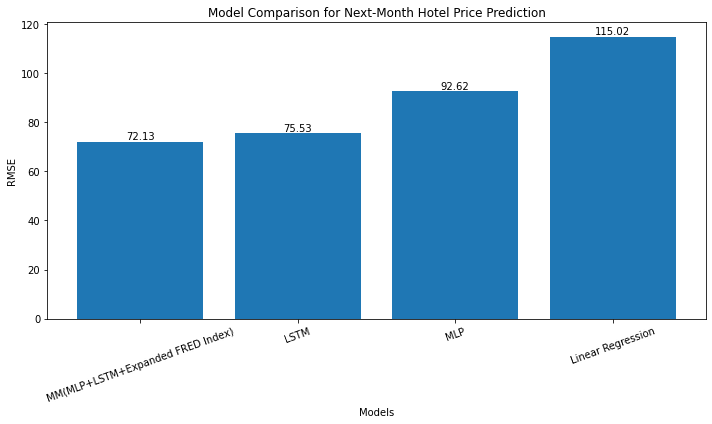

In [14]:
# Plot 1: main model comparison by RMSE
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df["Model"], results_df["RMSE"])

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h, f"{h:.2f}", ha="center", va="bottom")

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison for Next-Month Hotel Price Prediction")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


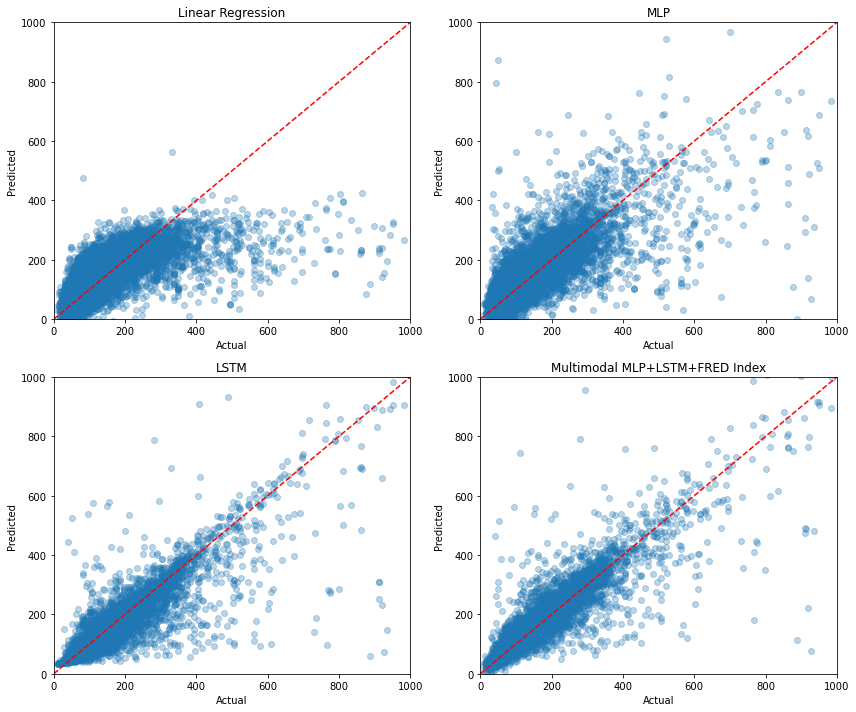

In [15]:
# Plot 2: actual vs predicted
plt.figure(figsize=(12, 10))

# 1 Linear Regression
plt.subplot(2, 2, 1)
plt.scatter(y_test_tab, pred_lr, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

# 2 MLP
plt.subplot(2, 2, 2)
plt.scatter(y_test_tab, pred_mlp, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("MLP")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

# 3 LSTM
plt.subplot(2, 2, 3)
plt.scatter(y_test_real, pred_lstm, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("LSTM")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

# 4 Multimodal
plt.subplot(2, 2, 4)
plt.scatter(y_test_real, pred_fusion, alpha=0.3)
plt.plot([0, 1000], [0, 1000], "r--")
plt.title("Multimodal MLP+LSTM+FRED Index")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xlim(0, 1000)
plt.ylim(0, 1000)

plt.tight_layout()
plt.show()


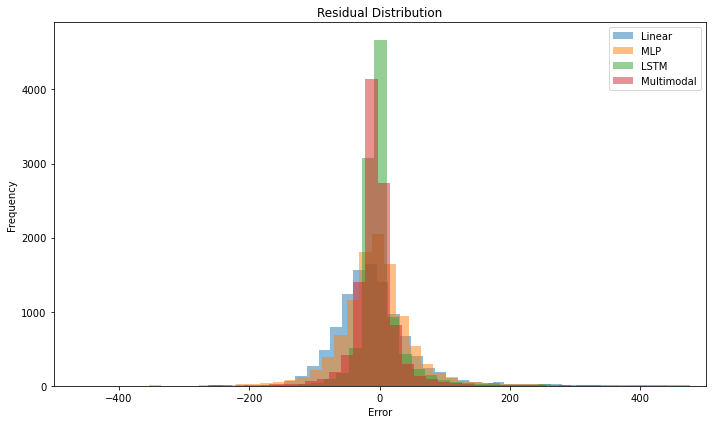

In [16]:
# Plot 3: residual distribution
err_lr = y_test_tab - pred_lr
err_mlp = y_test_tab - pred_mlp
err_lstm = y_test_real - pred_lstm
err_mm = y_test_real - pred_fusion

plt.figure(figsize=(10, 6))

limit = 500
mask_lr = np.abs(err_lr) < limit
mask_mlp = np.abs(err_mlp) < limit
mask_lstm = np.abs(err_lstm) < limit
mask_mm = np.abs(err_mm) < limit

plt.hist(err_lr[mask_lr], bins=50, alpha=0.5, label="Linear")
plt.hist(err_mlp[mask_mlp], bins=50, alpha=0.5, label="MLP")
plt.hist(err_lstm[mask_lstm], bins=50, alpha=0.5, label="LSTM")
plt.hist(err_mm[mask_mm], bins=50, alpha=0.5, label="Multimodal")

plt.legend()
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.xlim(-500, 500)
plt.tight_layout()
plt.show()


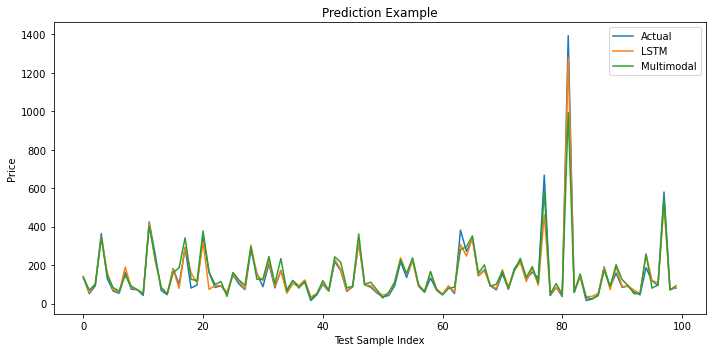

In [17]:
# Plot 4: time-series prediction example
plt.figure(figsize=(10, 5))
plt.plot(y_test_real[:100], label="Actual")
plt.plot(pred_lstm[:100], label="LSTM")
plt.plot(pred_fusion[:100], label="Multimodal")
plt.legend()
plt.title("Prediction Example")
plt.xlabel("Test Sample Index")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


In [18]:
# Predict next-month hotel price using the trained multimodal model

def predict_next_month_price(hotel_id, future_feature_overrides=None):
    """
    Predict next-month hotel price for one hotel.

    Parameters
    ----------
    hotel_id : selected hotel_id from df_full
    future_feature_overrides : optional dict
        Used when you want to manually set known future features,
        such as weekend, holiday, nnights, scarce_room, offer, etc.

    Returns
    -------
    dict containing hotel_id, forecast origin, target month, and predicted price.
    """

    if future_feature_overrides is None:
        future_feature_overrides = {}

    # 1. Get this hotel's historical records
    group = df_full[df_full["hotel_id"] == hotel_id].sort_values(["year", "month"]).reset_index(drop=True)

    if len(group) < sequence_length:
        raise ValueError(f"Hotel {hotel_id} does not have enough history for sequence_length={sequence_length}.")

    # 2. Use the latest available month as forecast origin
    latest_row = group.iloc[-1]

    origin_year = int(latest_row["year"])
    origin_month = int(latest_row["month"])

    # 3. Calculate next month
    origin_period = pd.Period(year=origin_year, month=origin_month, freq="M")
    target_period = origin_period + prediction_horizon

    target_year = target_period.year
    target_month = target_period.month

    # 4. Use the latest sequence_length prices as LSTM input
    hist_prices = group["price"].tail(sequence_length).values

    X_seq_future = hist_prices.reshape(1, sequence_length, 1)
    X_seq_future_scaled = scaler_x.transform(
        X_seq_future.reshape(-1, 1)
    ).reshape(1, sequence_length, 1)

    # 5. Build future tabular row
    future_row = {}

    for col in base_tabular_cols:
        if col == "year":
            future_row[col] = target_year
        elif col == "month":
            future_row[col] = target_month
        else:
            # By default, use latest known value
            future_row[col] = latest_row[col]

    # FRED variables use latest available month to avoid future leakage
    for col in exogenous_cols:
        future_row[col] = latest_row[col]

    # Manually override future features if provided
    for key, value in future_feature_overrides.items():
        future_row[key] = value

    X_future_raw = pd.DataFrame([future_row])

    # 6. One-hot encode categorical variables consistently with training
    combined_raw = pd.concat(
        [aligned_df[tabular_cols].copy(), X_future_raw[tabular_cols].copy()],
        ignore_index=True
    )

    combined_encoded = pd.get_dummies(
        combined_raw,
        columns=categorical_cols,
        drop_first=True
    )

    X_future_encoded = combined_encoded.iloc[[-1]]

    # Align with training columns
    X_future_encoded = X_future_encoded.reindex(columns=X_tab.columns, fill_value=0)

    X_future_encoded = X_future_encoded.replace([np.inf, -np.inf], np.nan)
    X_future_encoded = X_future_encoded.fillna(X_tab.mean(numeric_only=True))
    X_future_encoded = X_future_encoded.fillna(0)

    # 7. Scale tabular features
    X_future_tab_scaled = scaler_fusion_tab.transform(X_future_encoded)

    # 8. Predict
    pred_scaled = model_fusion.predict(
        [X_future_tab_scaled, X_seq_future_scaled],
        verbose=0
    ).flatten()

    pred_price = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()[0]

    return {
        "hotel_id": hotel_id,
        "origin_year": origin_year,
        "origin_month": origin_month,
        "target_year": target_year,
        "target_month": target_month,
        "predicted_next_month_price": pred_price
    }

In [19]:
prediction = predict_next_month_price(
    hotel_id=12345,
    future_feature_overrides={
        "weekend": 1,
        "holiday": 0,
        "nnights": 2,
        "scarce_room": 0
    }
)

prediction

{'hotel_id': 12345,
 'origin_year': 2018,
 'origin_month': 6,
 'target_year': 2018,
 'target_month': 7,
 'predicted_next_month_price': 76.95248}